In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [ ]:
BASE_DIR = Path(".")

OUTPUT_DIR = BASE_DIR / "data" / "output"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

## Load Forecast Evaluation Results

In [ ]:
results = pd.read_csv(
    OUTPUT_DIR / "forecast_results_evaluated.csv"
)

results["date"] = pd.to_datetime(
    results["date"]
)

In [ ]:
results.shape

(600, 11)

In [ ]:
results.head()

,date,estate_id,actual,forecast,model,error,absolute_error,residual,absolute_percentage_error,estate_name,region
0,2025-01-01,EST001,8385.6,9199.8,Naive,-814.2,814.2,-814.2,9.709502,Estate Lampung 01,Sumatra
1,2025-02-01,EST001,9219.1,9199.8,Naive,19.3,19.3,19.3,0.209348,Estate Lampung 01,Sumatra
2,2025-03-01,EST001,8661.8,9199.8,Naive,-538.0,538.0,-538.0,6.211180,Estate Lampung 01,Sumatra
3,2025-04-01,EST001,10508.3,9199.8,Naive,1308.5,1308.5,1308.5,12.452062,Estate Lampung 01,Sumatra
4,2025-05-01,EST001,10733.9,9199.8,Naive,1534.1,1534.1,1534.1,14.292103,Estate Lampung 01,Sumatra


In [ ]:
results.columns.tolist()

['date',
 'estate_id',
 'actual',
 'forecast',
 'model',
 'error',
 'absolute_error',
 'residual',
 'absolute_percentage_error',
 'estate_name',
 'region']

## Pilih Model Forecasting

In [ ]:
model_evaluation = pd.read_csv(
    OUTPUT_DIR / "overall_model_evaluation.csv"
)

model_evaluation

,model,MAE,RMSE,MAPE
0,Holt-Winters,788.138302,1001.911148,8.430236
1,Naive,975.953333,1228.357482,9.902923
2,Random Forest,160.650625,255.661940,1.648470
3,SARIMA,13765.835901,41841.305267,147.536486
4,Seasonal Naive,824.109583,1036.151644,8.651075


In [ ]:
model_evaluation.sort_values(
    "MAPE"
)

,model,MAE,RMSE,MAPE
2,Random Forest,160.650625,255.661940,1.648470
0,Holt-Winters,788.138302,1001.911148,8.430236
4,Seasonal Naive,824.109583,1036.151644,8.651075
1,Naive,975.953333,1228.357482,9.902923
3,SARIMA,13765.835901,41841.305267,147.536486


In [ ]:
selected_model = (
    model_evaluation
    .sort_values("MAPE")
    .iloc[0]["model"]
)

print("Selected model:", selected_model)

Selected model: Random Forest


## Filter Selected Model

In [ ]:
ew_df = results[
    results["model"] == selected_model
].copy()

In [ ]:
ew_df.shape

(120, 11)

In [ ]:
ew_df.head()

,date,estate_id,actual,forecast,model,error,absolute_error,residual,absolute_percentage_error,estate_name,region
480,2025-01-01,EST001,8385.6,8511.103005,Random Forest,-125.503005,125.503005,-125.503005,1.496649,Estate Lampung 01,Sumatra
481,2025-02-01,EST001,9219.1,9295.416363,Random Forest,-76.316363,76.316363,-76.316363,0.827807,Estate Lampung 01,Sumatra
482,2025-03-01,EST001,8661.8,8733.641644,Random Forest,-71.841644,71.841644,-71.841644,0.829408,Estate Lampung 01,Sumatra
483,2025-04-01,EST001,10508.3,10290.192226,Random Forest,218.107774,218.107774,218.107774,2.075576,Estate Lampung 01,Sumatra
484,2025-05-01,EST001,10733.9,10741.913551,Random Forest,-8.013551,8.013551,-8.013551,0.074656,Estate Lampung 01,Sumatra


## Hitung Forecast Deviation
##### hitung deviasi antara actual dan forecast.
> Deviation (%) =
(Actual - Forecast) / Forecast × 100

In [ ]:
ew_df["deviation_pct"] = (
    (
        ew_df["actual"] -
        ew_df["forecast"]
    )
    / ew_df["forecast"]
) * 100

In [ ]:
ew_df[
    [
        "date",
        "estate_id",
        "actual",
        "forecast",
        "deviation_pct"
    ]
].head(10)

,date,estate_id,actual,forecast,deviation_pct
480,2025-01-01,EST001,8385.6,8511.103005,-1.474580
481,2025-02-01,EST001,9219.1,9295.416363,-0.821011
482,2025-03-01,EST001,8661.8,8733.641644,-0.822585
483,2025-04-01,EST001,10508.3,10290.192226,2.119569
484,2025-05-01,EST001,10733.9,10741.913551,-0.074601
485,2025-06-01,EST001,7719.9,9010.199718,-14.320434
486,2025-07-01,EST001,9791.0,10080.444097,-2.871343
487,2025-08-01,EST001,10124.1,10212.086874,-0.861595
488,2025-09-01,EST001,10449.1,10447.380097,0.016463
489,2025-10-01,EST001,9599.1,9514.896718,0.884963


## Buat Business Rule

In [ ]:
def classify_warning(deviation):

    if deviation >= -5:
        return "Normal"

    elif deviation >= -10:
        return "Warning"

    else:
        return "Critical"

In [ ]:
ew_df["warning_status"] = (
    ew_df["deviation_pct"]
    .apply(classify_warning)
)

In [ ]:
ew_df[
    [
        "date",
        "estate_id",
        "actual",
        "forecast",
        "deviation_pct",
        "warning_status"
    ]
].head(15)

,date,estate_id,actual,forecast,deviation_pct,warning_status
480,2025-01-01,EST001,8385.6,8511.103005,-1.474580,Normal
481,2025-02-01,EST001,9219.1,9295.416363,-0.821011,Normal
482,2025-03-01,EST001,8661.8,8733.641644,-0.822585,Normal
483,2025-04-01,EST001,10508.3,10290.192226,2.119569,Normal
484,2025-05-01,EST001,10733.9,10741.913551,-0.074601,Normal
485,2025-06-01,EST001,7719.9,9010.199718,-14.320434,Critical
486,2025-07-01,EST001,9791.0,10080.444097,-2.871343,Normal
487,2025-08-01,EST001,10124.1,10212.086874,-0.861595,Normal
488,2025-09-01,EST001,10449.1,10447.380097,0.016463,Normal
489,2025-10-01,EST001,9599.1,9514.896718,0.884963,Normal


## Warning Distribution

In [ ]:
warning_distribution = (
    ew_df["warning_status"]
    .value_counts()
)

warning_distribution

,count
warning_status,
Normal,117
Warning,2
Critical,1


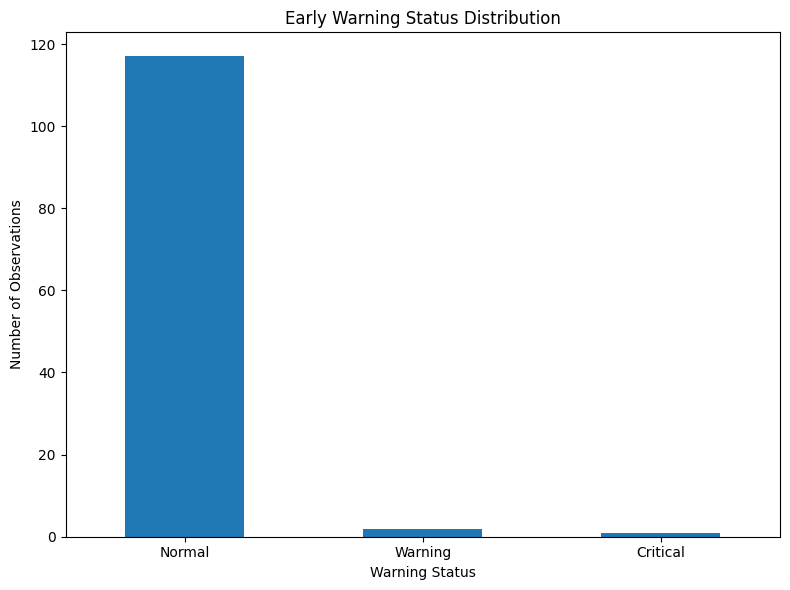

In [ ]:
plt.figure(figsize=(8, 6))

warning_distribution.plot(
    kind="bar"
)

plt.title("Early Warning Status Distribution")
plt.xlabel("Warning Status")
plt.ylabel("Number of Observations")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Warning Percentage

In [ ]:
warning_percentage = (
    ew_df["warning_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

warning_percentage

,proportion
warning_status,
Normal,97.50
Warning,1.67
Critical,0.83


## Critical Alerts

In [ ]:
critical_alerts = ew_df[
    ew_df["warning_status"] == "Critical"
].copy()

In [ ]:
critical_alerts[
    [
        "date",
        "estate_id",
        "estate_name",
        "region",
        "actual",
        "forecast",
        "deviation_pct",
        "warning_status"
    ]
].sort_values(
    "deviation_pct"
)

,date,estate_id,estate_name,region,actual,forecast,deviation_pct,warning_status
485,2025-06-01,EST001,Estate Lampung 01,Sumatra,7719.9,9010.199718,-14.320434,Critical


## Warning Alerts

In [ ]:
warning_alerts = ew_df[
    ew_df["warning_status"] == "Warning"
].copy()

In [ ]:
warning_alerts[
    [
        "date",
        "estate_id",
        "estate_name",
        "region",
        "actual",
        "forecast",
        "deviation_pct",
        "warning_status"
    ]
].sort_values(
    "deviation_pct"
)

,date,estate_id,estate_name,region,actual,forecast,deviation_pct,warning_status
499,2025-08-01,EST002,Estate Lampung 02,Sumatra,7658.6,8288.042196,-7.594582,Warning
572,2025-09-01,EST008,Estate Kaltim 01,Kalimantan,7989.1,8586.473727,-6.957148,Warning


## Semua Alerts

In [ ]:
alerts = ew_df[
    ew_df["warning_status"].isin(
        ["Warning", "Critical"]
    )
].copy()

In [ ]:
alerts = alerts.sort_values(
    ["date", "deviation_pct"]
)

In [ ]:
alerts.head(20)

,date,estate_id,actual,forecast,model,error,absolute_error,residual,absolute_percentage_error,estate_name,region,deviation_pct,warning_status
485,2025-06-01,EST001,7719.9,9010.199718,Random Forest,-1290.299718,1290.299718,-1290.299718,16.713943,Estate Lampung 01,Sumatra,-14.320434,Critical
499,2025-08-01,EST002,7658.6,8288.042196,Random Forest,-629.442196,629.442196,-629.442196,8.218763,Estate Lampung 02,Sumatra,-7.594582,Warning
572,2025-09-01,EST008,7989.1,8586.473727,Random Forest,-597.373727,597.373727,-597.373727,7.477359,Estate Kaltim 01,Kalimantan,-6.957148,Warning


## Alert per Estate

In [ ]:
estate_alert_summary = (
    ew_df.groupby(
        ["estate_id", "estate_name"]
    )
    .agg(
        total_observations=(
            "warning_status",
            "size"
        ),
        normal_count=(
            "warning_status",
            lambda x: (x == "Normal").sum()
        ),
        warning_count=(
            "warning_status",
            lambda x: (x == "Warning").sum()
        ),
        critical_count=(
            "warning_status",
            lambda x: (x == "Critical").sum()
        ),
        avg_deviation_pct=(
            "deviation_pct",
            "mean"
        ),
        min_deviation_pct=(
            "deviation_pct",
            "min"
        )
    )
    .reset_index()
)

In [ ]:
estate_alert_summary

,estate_id,estate_name,total_observations,normal_count,warning_count,critical_count,avg_deviation_pct,min_deviation_pct
0,EST001,Estate Lampung 01,12,11,0,1,-1.806063,-14.320434
1,EST002,Estate Lampung 02,12,11,1,0,-1.809395,-7.594582
2,EST003,Estate Sumsel 01,12,12,0,0,-0.268852,-1.915094
3,EST004,Estate Jambi 01,12,12,0,0,0.041856,-1.596011
4,EST005,Estate Riau 01,12,12,0,0,2.021352,-2.895647
5,EST006,Estate Kalbar 01,12,12,0,0,-0.467176,-3.852192
6,EST007,Estate Kalteng 01,12,12,0,0,0.100400,-2.087561
7,EST008,Estate Kaltim 01,12,11,1,0,-0.688724,-6.957148
8,EST009,Estate Sulawesi 01,12,12,0,0,0.685738,-3.788149
9,EST010,Estate Sulawesi 02,12,12,0,0,-1.332026,-3.464045


## Critical Alert Rate

In [ ]:
# persentase Critical per estate.
estate_alert_summary["critical_rate_pct"] = (
    estate_alert_summary["critical_count"]
    / estate_alert_summary["total_observations"]
) * 100

In [ ]:
# warning rate
estate_alert_summary["warning_rate_pct"] = (
    estate_alert_summary["warning_count"]
    / estate_alert_summary["total_observations"]
) * 100

In [ ]:
estate_alert_summary

,estate_id,estate_name,total_observations,normal_count,warning_count,critical_count,avg_deviation_pct,min_deviation_pct,critical_rate_pct,warning_rate_pct
0,EST001,Estate Lampung 01,12,11,0,1,-1.806063,-14.320434,8.333333,0.000000
1,EST002,Estate Lampung 02,12,11,1,0,-1.809395,-7.594582,0.000000,8.333333
2,EST003,Estate Sumsel 01,12,12,0,0,-0.268852,-1.915094,0.000000,0.000000
3,EST004,Estate Jambi 01,12,12,0,0,0.041856,-1.596011,0.000000,0.000000
4,EST005,Estate Riau 01,12,12,0,0,2.021352,-2.895647,0.000000,0.000000
5,EST006,Estate Kalbar 01,12,12,0,0,-0.467176,-3.852192,0.000000,0.000000
6,EST007,Estate Kalteng 01,12,12,0,0,0.100400,-2.087561,0.000000,0.000000
7,EST008,Estate Kaltim 01,12,11,1,0,-0.688724,-6.957148,0.000000,8.333333
8,EST009,Estate Sulawesi 01,12,12,0,0,0.685738,-3.788149,0.000000,0.000000
9,EST010,Estate Sulawesi 02,12,12,0,0,-1.332026,-3.464045,0.000000,0.000000


## Visual Critical Alerts by Estate

In [ ]:
critical_by_estate = (
    estate_alert_summary
    .sort_values("critical_count", ascending=False)
)

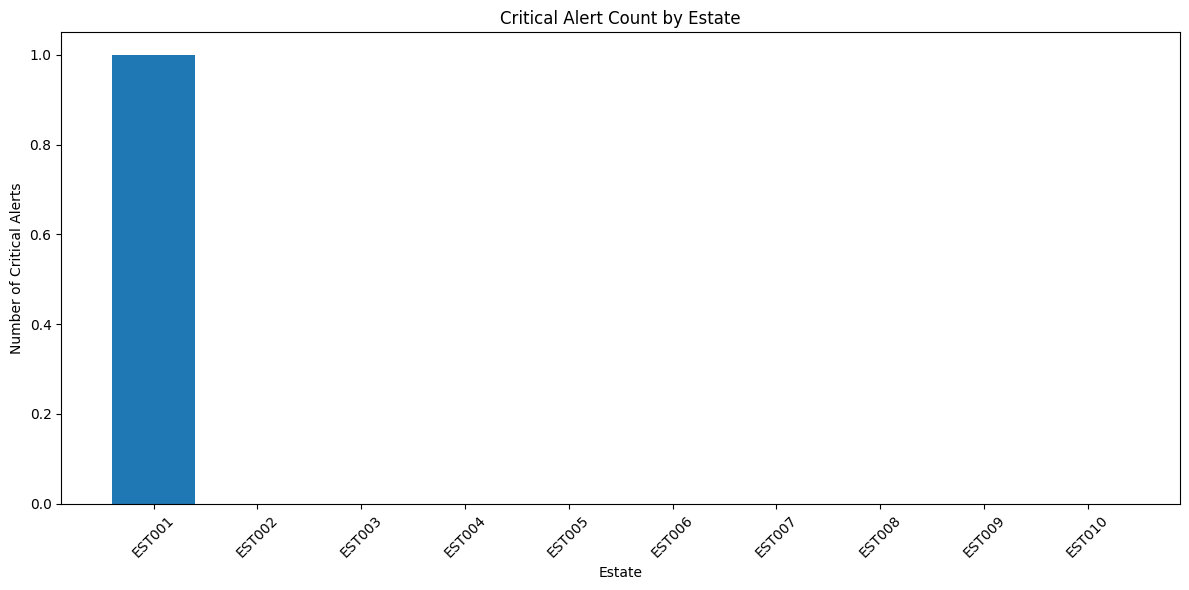

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    critical_by_estate["estate_id"],
    critical_by_estate["critical_count"]
)

plt.title("Critical Alert Count by Estate")
plt.xlabel("Estate")
plt.ylabel("Number of Critical Alerts")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Alert by Region

In [ ]:
region_alert_summary = (
    ew_df.groupby("region")
    .agg(
        total_observations=(
            "warning_status",
            "size"
        ),
        normal_count=(
            "warning_status",
            lambda x: (x == "Normal").sum()
        ),
        warning_count=(
            "warning_status",
            lambda x: (x == "Warning").sum()
        ),
        critical_count=(
            "warning_status",
            lambda x: (x == "Critical").sum()
        ),
        avg_deviation_pct=(
            "deviation_pct",
            "mean"
        )
    )
    .reset_index()
)

In [ ]:
region_alert_summary

,region,total_observations,normal_count,warning_count,critical_count,avg_deviation_pct
0,Kalimantan,36,35,1,0,-0.351833
1,Sulawesi,24,24,0,0,-0.323144
2,Sumatra,60,58,1,1,-0.364220


## Regional Critical Rate

In [ ]:
region_alert_summary["critical_rate_pct"] = (
    region_alert_summary["critical_count"]
    / region_alert_summary["total_observations"]
) * 100

In [ ]:
region_alert_summary

,region,total_observations,normal_count,warning_count,critical_count,avg_deviation_pct,critical_rate_pct
0,Kalimantan,36,35,1,0,-0.351833,0.000000
1,Sulawesi,24,24,0,0,-0.323144,0.000000
2,Sumatra,60,58,1,1,-0.364220,1.666667


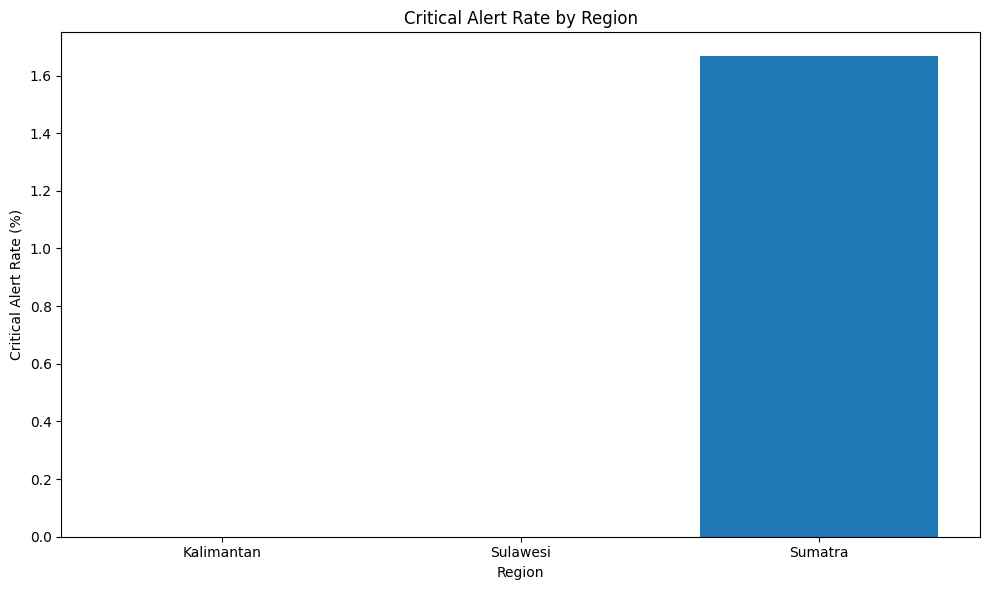

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    region_alert_summary["region"],
    region_alert_summary["critical_rate_pct"]
)

plt.title("Critical Alert Rate by Region")
plt.xlabel("Region")
plt.ylabel("Critical Alert Rate (%)")

plt.tight_layout()
plt.show()

## Monthly Alert Trend

In [ ]:
monthly_alert = (
    ew_df.groupby(
        ["date", "warning_status"]
    )
    .size()
    .reset_index(
        name="count"
    )
)

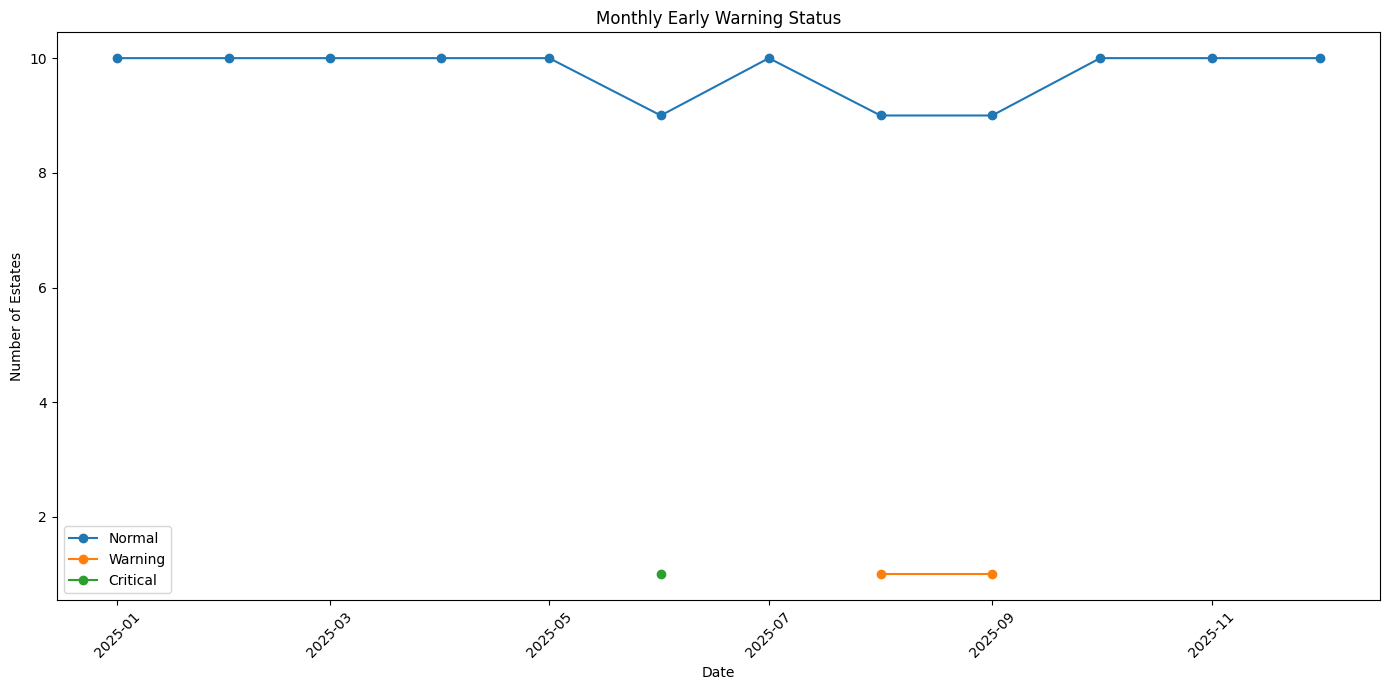

In [ ]:
plt.figure(figsize=(14, 7))

for status in [
    "Normal",
    "Warning",
    "Critical"
]:

    status_data = monthly_alert[
        monthly_alert["warning_status"] == status
    ]

    plt.plot(
        status_data["date"],
        status_data["count"],
        marker="o",
        label=status
    )

plt.title("Monthly Early Warning Status")
plt.xlabel("Date")
plt.ylabel("Number of Estates")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Actual vs Forecast + Warning

In [ ]:
selected_estate = ew_df[
    "estate_id"
].iloc[0]

estate_data = ew_df[
    ew_df["estate_id"] == selected_estate
].sort_values("date")

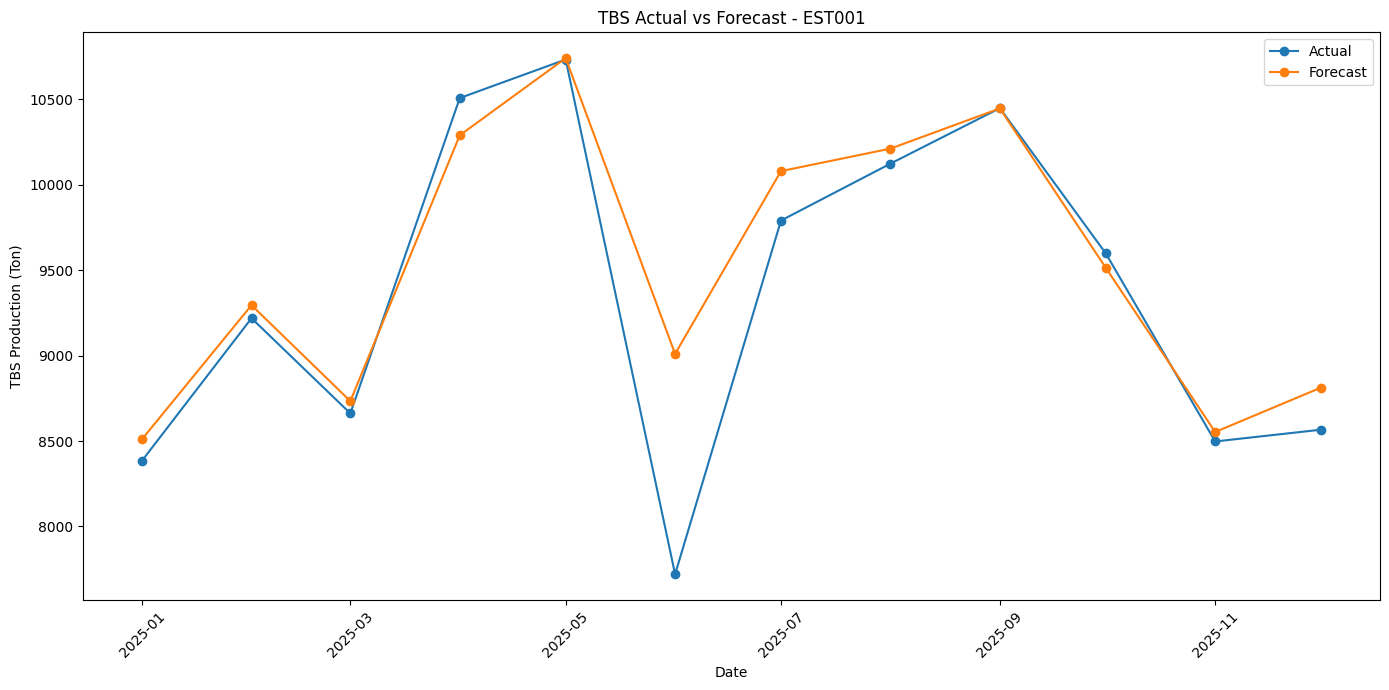

In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(
    estate_data["date"],
    estate_data["actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    estate_data["date"],
    estate_data["forecast"],
    marker="o",
    label="Forecast"
)

plt.title(
    f"TBS Actual vs Forecast - {selected_estate}"
)

plt.xlabel("Date")
plt.ylabel("TBS Production (Ton)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Deviation Trend

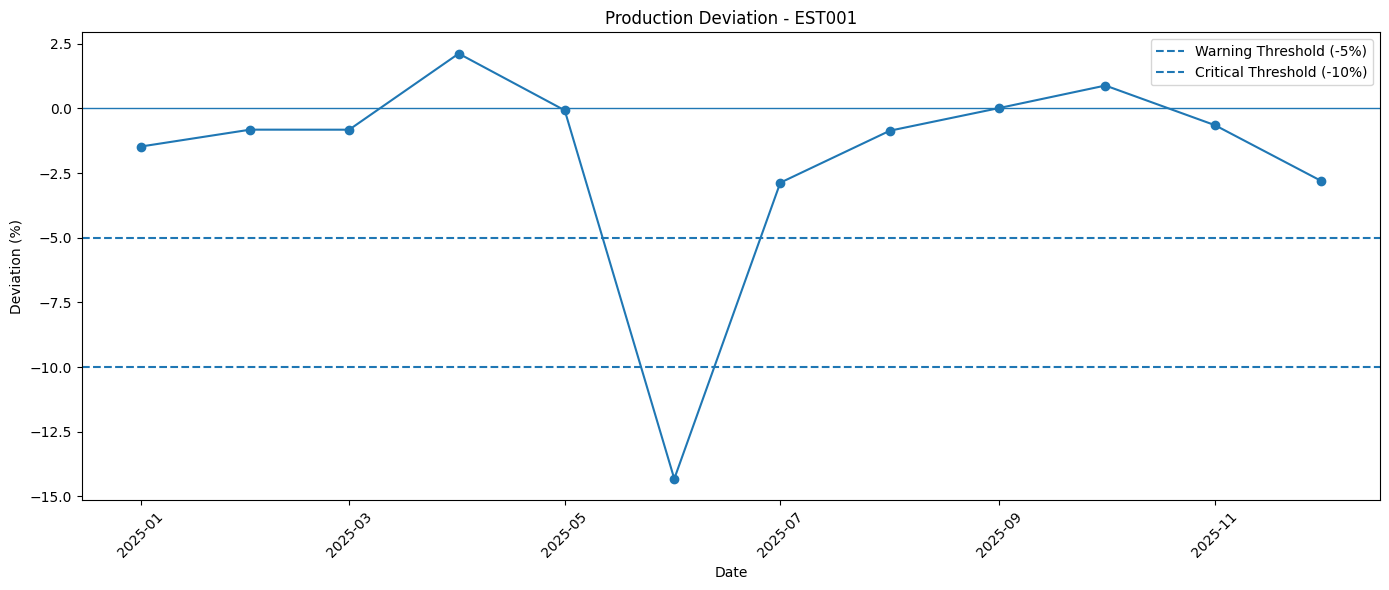

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    estate_data["date"],
    estate_data["deviation_pct"],
    marker="o"
)

plt.axhline(
    -5,
    linestyle="--",
    label="Warning Threshold (-5%)"
)

plt.axhline(
    -10,
    linestyle="--",
    label="Critical Threshold (-10%)"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    f"Production Deviation - {selected_estate}"
)

plt.xlabel("Date")
plt.ylabel("Deviation (%)")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Severity Score

In [ ]:
severity_mapping = {
    "Normal": 0,
    "Warning": 1,
    "Critical": 2
}

ew_df["severity_score"] = (
    ew_df["warning_status"]
    .map(severity_mapping)
)

## Buat Alert Message

In [ ]:
def generate_alert_message(row):

    if row["warning_status"] == "Critical":
        return (
            f"Critical production deviation detected at "
            f"{row['estate_name']}. "
            f"Actual production is "
            f"{abs(row['deviation_pct']):.1f}% below forecast."
        )

    elif row["warning_status"] == "Warning":
        return (
            f"Production deviation detected at "
            f"{row['estate_name']}. "
            f"Actual production is "
            f"{abs(row['deviation_pct']):.1f}% below forecast."
        )

    else:
        return "Production is within the normal forecast range."

In [ ]:
ew_df["alert_message"] = (
    ew_df.apply(
        generate_alert_message,
        axis=1
    )
)

In [ ]:
ew_df[
    [
        "date",
        "estate_name",
        "warning_status",
        "deviation_pct",
        "alert_message"
    ]
].head(15)

,date,estate_name,warning_status,deviation_pct,alert_message
480,2025-01-01,Estate Lampung 01,Normal,-1.474580,Production is within the normal forecast range.
481,2025-02-01,Estate Lampung 01,Normal,-0.821011,Production is within the normal forecast range.
482,2025-03-01,Estate Lampung 01,Normal,-0.822585,Production is within the normal forecast range.
483,2025-04-01,Estate Lampung 01,Normal,2.119569,Production is within the normal forecast range.
484,2025-05-01,Estate Lampung 01,Normal,-0.074601,Production is within the normal forecast range.
485,2025-06-01,Estate Lampung 01,Critical,-14.320434,Critical production deviation detected at Esta...
486,2025-07-01,Estate Lampung 01,Normal,-2.871343,Production is within the normal forecast range.
487,2025-08-01,Estate Lampung 01,Normal,-0.861595,Production is within the normal forecast range.
488,2025-09-01,Estate Lampung 01,Normal,0.016463,Production is within the normal forecast range.
489,2025-10-01,Estate Lampung 01,Normal,0.884963,Production is within the normal forecast range.


## Buat Operational Alert Table

In [ ]:
alert_output = ew_df[
    [
        "date",
        "estate_id",
        "estate_name",
        "region",
        "actual",
        "forecast",
        "deviation_pct",
        "warning_status",
        "severity_score",
        "alert_message"
    ]
].copy()

In [ ]:
alert_output = alert_output.sort_values(
    ["date", "severity_score"],
    ascending=[True, False]
)

In [ ]:
print("Alert output shape:", alert_output.shape)

print("\nForecast summary in alert_output:")
print(alert_output["forecast"].describe())

print("\nMaximum forecast:")
print(alert_output["forecast"].max())

print("\nLargest forecasts:")
display(
    alert_output[
        ["date", "estate_id", "actual", "forecast"]
    ]
    .sort_values("forecast", ascending=False)
    .head(10)
)

Alert output shape: (120, 10)

Forecast summary in alert_output:
count      120.000000
mean      9773.703639
std       1398.841299
min       6598.771308
25%       8943.306101
50%       9821.296521
75%      10745.786643
max      13236.272896
Name: forecast, dtype: float64

Maximum forecast:
13236.272896398506

Largest forecasts:


,date,estate_id,actual,forecast
536,2025-09-01,EST005,14292.4,13236.272896
533,2025-06-01,EST005,13354.1,12882.678659
537,2025-10-01,EST005,13589.2,12665.358715
538,2025-11-01,EST005,12914.1,12566.931717
521,2025-06-01,EST004,13146.8,12555.944717
534,2025-07-01,EST005,12998.4,12504.994465
557,2025-06-01,EST007,12584.7,12094.720182
507,2025-04-01,EST003,11862.5,11954.200488
530,2025-03-01,EST005,11756.6,11866.204149
558,2025-07-01,EST007,11966.9,11807.874881


In [ ]:
check_saved = pd.read_csv(
    OUTPUT_DIR / "early_warning.csv"
)

print(check_saved.shape)
print(check_saved["forecast"].describe())
print("MAX SAVED:", check_saved["forecast"].max())

(120, 10)
count      120.000000
mean      9773.703639
std       1398.841299
min       6598.771308
25%       8943.306101
50%       9821.296521
75%      10745.786643
max      13236.272896
Name: forecast, dtype: float64
MAX SAVED: 13236.272896398506


## Save Early Warning Results

In [ ]:
estate_alert_summary.to_csv(
    OUTPUT_DIR / "estate_alert_summary.csv",
    index=False
)

In [ ]:
region_alert_summary.to_csv(
    OUTPUT_DIR / "region_alert_summary.csv",
    index=False
)

## Final Summary

In [ ]:
print("=" * 60)
print("EARLY WARNING SYSTEM SUMMARY")
print("=" * 60)

print(f"\nSelected Forecast Model: {selected_model}")

print("\nWarning Distribution:")
display(
    warning_percentage
)

print("\nEstate Alert Summary:")
display(
    estate_alert_summary
)

print("\nRegional Alert Summary:")
display(
    region_alert_summary
)

EARLY WARNING SYSTEM SUMMARY

Selected Forecast Model: Random Forest

Warning Distribution:


,proportion
warning_status,
Normal,97.50
Warning,1.67
Critical,0.83



Estate Alert Summary:


,estate_id,estate_name,total_observations,normal_count,warning_count,critical_count,avg_deviation_pct,min_deviation_pct,critical_rate_pct,warning_rate_pct
0,EST001,Estate Lampung 01,12,11,0,1,-1.806063,-14.320434,8.333333,0.000000
1,EST002,Estate Lampung 02,12,11,1,0,-1.809395,-7.594582,0.000000,8.333333
2,EST003,Estate Sumsel 01,12,12,0,0,-0.268852,-1.915094,0.000000,0.000000
3,EST004,Estate Jambi 01,12,12,0,0,0.041856,-1.596011,0.000000,0.000000
4,EST005,Estate Riau 01,12,12,0,0,2.021352,-2.895647,0.000000,0.000000
5,EST006,Estate Kalbar 01,12,12,0,0,-0.467176,-3.852192,0.000000,0.000000
6,EST007,Estate Kalteng 01,12,12,0,0,0.100400,-2.087561,0.000000,0.000000
7,EST008,Estate Kaltim 01,12,11,1,0,-0.688724,-6.957148,0.000000,8.333333
8,EST009,Estate Sulawesi 01,12,12,0,0,0.685738,-3.788149,0.000000,0.000000
9,EST010,Estate Sulawesi 02,12,12,0,0,-1.332026,-3.464045,0.000000,0.000000



Regional Alert Summary:


,region,total_observations,normal_count,warning_count,critical_count,avg_deviation_pct,critical_rate_pct
0,Kalimantan,36,35,1,0,-0.351833,0.000000
1,Sulawesi,24,24,0,0,-0.323144,0.000000
2,Sumatra,60,58,1,1,-0.364220,1.666667


In [ ]:
selected_results = results[
    results["model"] == selected_model
].copy()

print("Selected model:", selected_model)

print("\nForecast summary:")
print(
    selected_results["forecast"].describe()
)

print("\nLargest forecasts:")
display(
    selected_results[
        ["date", "estate_id", "actual", "forecast"]
    ]
    .sort_values("forecast", ascending=False)
    .head(10)
)

Selected model: Random Forest

Forecast summary:
count      120.000000
mean      9773.703639
std       1398.841299
min       6598.771308
25%       8943.306101
50%       9821.296521
75%      10745.786643
max      13236.272896
Name: forecast, dtype: float64

Largest forecasts:


,date,estate_id,actual,forecast
536,2025-09-01,EST005,14292.4,13236.272896
533,2025-06-01,EST005,13354.1,12882.678659
537,2025-10-01,EST005,13589.2,12665.358715
538,2025-11-01,EST005,12914.1,12566.931717
521,2025-06-01,EST004,13146.8,12555.944717
534,2025-07-01,EST005,12998.4,12504.994465
557,2025-06-01,EST007,12584.7,12094.720182
507,2025-04-01,EST003,11862.5,11954.200488
530,2025-03-01,EST005,11756.6,11866.204149
558,2025-07-01,EST007,11966.9,11807.874881
